In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from xgboost import XGBRegressor

## Visualizacion de datos.

In [2]:
df = pd.read_csv("../data/raw/farmacia-datos.csv", sep=";", encoding="latin1")
df.head()

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Fisc. Numero,Tipo Pago,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar
0,01/01/25 01.13.46,F,B,0,379923,NaN,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,NaN,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,NaN,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"


In [3]:
df.shape

(117415, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117415 entries, 0 to 117414
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             117415 non-null  object 
 1   Tipo Mov.         117415 non-null  object 
 2   Fac. Tipo         117415 non-null  object 
 3   Fac. Suc.         117415 non-null  int64  
 4   Fac. Nun.         117415 non-null  int64  
 5   Fisc. Numero      0 non-null       float64
 6   Tipo Pago         117415 non-null  object 
 7   Cant.             117415 non-null  int64  
 8   Precio            117415 non-null  object 
 9   Producto          117414 non-null  object 
 10  Sub. Total        117415 non-null  object 
 11  Rubro             117415 non-null  object 
 12  Cobertura         117415 non-null  object 
 13  Ajustes           117415 non-null  int64  
 14  Desc. Adic.       117415 non-null  object 
 15  Total. Cliente    117415 non-null  object 
 16  IVA               11

In [5]:
df.duplicated().sum()

np.int64(121)

In [6]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.duplicated().sum()

np.int64(0)

### Observaciones
>
>Logramo visualizar los datos. En  cada linea podemos entender que es una compra. algunas comparten el mismo numero de ticket lo que nos da a entender que cada linea es un articulo que se compro, algunas variables categoricas parecen ser numericas, las estudiaremos para modificarlas si se necesita. Encontramos unos duplicados pero para descartarlas tomamos la decision de evaluarlas antes para tener una decision mas acertada. Tenemos 20 columnas y estudiaremos cada una de ellas.
>
>En el analisis inicial notamos tambien que la fila `Fisc. Numero` no tiene ningun valor en ninguna columna. asi que procederemos a borrar directamente esa columna.
>Tambien 

In [7]:
df.drop(["Fisc. Numero"],
              axis=1, inplace=True)

## Analisis de variables.

### Analisis de variables categoricas

>Empezaremos evaluando las variables categoricas para evaluar que contiene cada una de ellas.

In [8]:
cat_variables = df.select_dtypes(include=['object']).columns.tolist()
cat_variables

['Fecha',
 'Tipo Mov.',
 'Fac. Tipo',
 'Tipo Pago',
 'Precio',
 'Producto',
 'Sub. Total',
 'Rubro',
 'Cobertura',
 'Desc. Adic.',
 'Total. Cliente',
 'IVA',
 'Total Gravado',
 'Total sin Gravar']

In [9]:
df[cat_variables].head()

,Fecha,Tipo Mov.,Fac. Tipo,Tipo Pago,Precio,Producto,Sub. Total,Rubro,Cobertura,Desc. Adic.,Total. Cliente,IVA,Total Gravado,Total sin Gravar
0,01/01/25 01.13.46,F,B,E,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,9344,0,0,9344
1,01/01/25 01.59.21,F,B,E,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,"5142,11",0,0,"8174,96"
2,01/01/25 02.01.59,F,B,E,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,"2856,86",0,0,"8174,96"
3,01/01/25 02.04.14,F,B,E,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,"8086,82",0,0,"8086,82"
4,01/01/25 02.08.35,F,B,E,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,"26750,12",0,0,"26750,12"


In [10]:
df["Tipo Mov."].value_counts()

Tipo Mov.
F    117294
Name: count, dtype: int64

In [11]:
df["Fac. Tipo"].value_counts()

Fac. Tipo
B    117131
A       163
Name: count, dtype: int64

In [12]:
df["Tipo Pago"].value_counts()

Tipo Pago
E    117294
Name: count, dtype: int64

In [13]:
df["Producto"].value_counts()

Producto
GEN LP IBUPROFENO blister 600 mg x 10      1925
GEN LP OMEPRAZOL blister 20 mg x 15        1203
ASPIRINA PREVENT comp.cub.enterica x 50    1149
TAFIROL 1G X 8 (unica)                      870
TAFIROL 1 G comp.ran.x 50                   699
                                           ... 
NOCTE 10 10 mg comp.x 30                      1
AVENT CHUPETE (unica)                         1
CEPILLO ORAL B (unica)                        1
PAMPERS PANTS PREMIUM CARE XGD                1
APOSITO IQP (unica)                           1
Name: count, Length: 7675, dtype: int64

In [14]:
df["Rubro"].value_counts()

Rubro
FARMACIA           108277
PERFUMERIA           8916
NO ESPECIFICADO       101
Name: count, dtype: int64

In [15]:
df["Desc. Adic."].value_counts()

Desc. Adic.
0             115152
-3,64E-12        226
-1,82E-12         86
-7,28E-12         79
-9,09E-13         24
               ...  
1450               1
8741,37096         1
4704,488           1
231,56             1
1148               1
Name: count, Length: 1155, dtype: int64

In [16]:
df["IVA"].value_counts()

IVA
0              94474
173,553719       982
520,661157       673
867,768595       658
780,9917355      641
               ...  
1818,81            1
2965,42562         1
3529,132959        1
1662,644628        1
4252,447517        1
Name: count, Length: 4217, dtype: int64

In [17]:
df["Total Gravado"].value_counts()

Total Gravado
0              94474
826,446281       982
2479,338843      673
4132,231405      658
3719,008264      641
               ...  
8661               1
14121,07438        1
16805,39504        1
7917,355372        1
20249,75008        1
Name: count, Length: 4217, dtype: int64

In [18]:
df["Total sin Gravar"].value_counts()

Total sin Gravar
0           22003
3500         1410
5000         1376
4000         1316
3000          758
            ...  
9783            1
6942,08         1
26376,02        1
19010           1
9646,28         1
Name: count, Length: 26927, dtype: int64

#### Procederemos a ejecutar las siguientes acciones.

>1. Borraremos las variables `Tipo Mov.` y `Tipo Pago` por que todas las variables de cada columna tienen un valor unico que se repite. no aportaria nada realmente al Dataset y procederemos a borrarlo.
>2. Las variables `Precio`, `Sub. Total`, `Cobertura`, `Desc. Adic.`, `Total. Cliente`, `IVA`, `Total Gravado`, `Total sin Gravar` notamos que son variables numericas. las cambiaremos a flotantes para poder trabajarlas como variables numericas. 

In [19]:
df.drop(["Tipo Mov.", "Tipo Pago"],
              axis=1, inplace=True)

In [20]:
fals_obj = ["Precio","Sub. Total","Cobertura","Desc. Adic.","Total. Cliente","IVA","Total Gravado","Total sin Gravar"]

df[fals_obj] = df[fals_obj].astype(str).apply(lambda col: col.str.replace(",", "."))
df[fals_obj] = df[fals_obj].apply(pd.to_numeric)

In [21]:
df[fals_obj]

,Precio,Sub. Total,Cobertura,Desc. Adic.,Total. Cliente,IVA,Total Gravado,Total sin Gravar
0,9344.00,9344.00,0.00,0.0,9344.00,0.000000,0.0000,9344.00
1,8174.96,8174.96,3032.85,0.0,5142.11,0.000000,0.0000,8174.96
2,8174.96,8174.96,5318.10,0.0,2856.86,0.000000,0.0000,8174.96
3,8086.82,8086.82,0.00,0.0,8086.82,0.000000,0.0000,8086.82
4,26750.12,26750.12,0.00,0.0,26750.12,0.000000,0.0000,26750.12
...,...,...,...,...,...,...,...,...
117289,5000.00,5000.00,0.00,0.0,5000.00,0.000000,0.0000,5000.00
117290,13641.20,13641.20,5808.98,0.0,7832.22,0.000000,0.0000,13641.20
117291,16000.00,16000.00,0.00,0.0,16000.00,2776.859504,13223.1405,0.00
117292,36758.39,36758.39,14703.36,0.0,22055.03,0.000000,0.0000,36758.39


In [22]:
cat_variables = df.select_dtypes(include=['object']).columns.tolist()
cat_variables

['Fecha', 'Fac. Tipo', 'Producto', 'Rubro']

#### Procederemos a ejecutar las siguientes acciones.

>Analizaremos las variables `Fecha`, `Fac. Tipo`, `Producto`, `Rubro` que tenemos como categoricas para entender las variables a mayor profundidad.

In [23]:
df["Fecha"]

0         01/01/25 01.13.46
1         01/01/25 01.59.21
2         01/01/25 02.01.59
3         01/01/25 02.04.14
4         01/01/25 02.08.35
                ...        
117289    23/12/25 10.23.06
117290    23/12/25 10.25.57
117291    23/12/25 10.34.31
117292    23/12/25 10.38.49
117293    23/12/25 10.53.40
Name: Fecha, Length: 117294, dtype: object

In [24]:
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%d/%m/%y %H.%M.%S")

In [25]:
df["Fecha"].head()

0   2025-01-01 01:13:46
1   2025-01-01 01:59:21
2   2025-01-01 02:01:59
3   2025-01-01 02:04:14
4   2025-01-01 02:08:35
Name: Fecha, dtype: datetime64[ns]

In [26]:
df["num_semana"] = df["Fecha"].dt.isocalendar().week.astype(int)

In [27]:
df_copy = df.copy()

<Axes: xlabel='hora'>

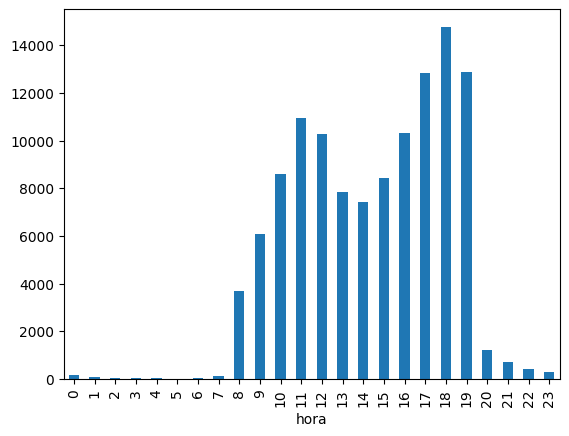

In [28]:
df_copy["hora"] = df_copy["Fecha"].dt.hour
df_copy["hora"].value_counts().sort_index().plot(kind="bar")

<Axes: xlabel='day_num'>

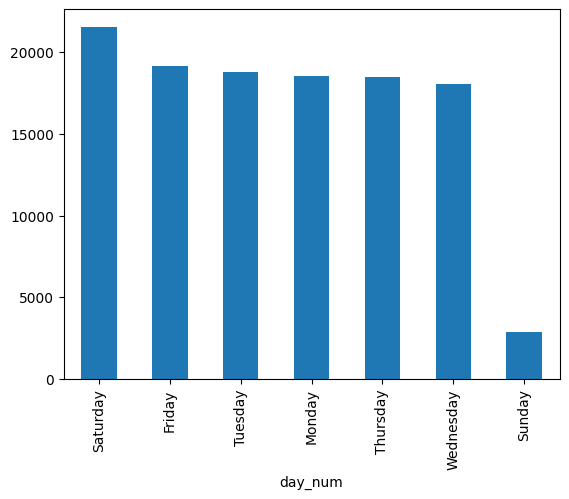

In [29]:
df_copy["day_num"] = df_copy["Fecha"].dt.day_name()
df_copy["day_num"].value_counts().plot(kind="bar")

<Axes: xlabel='Fecha'>

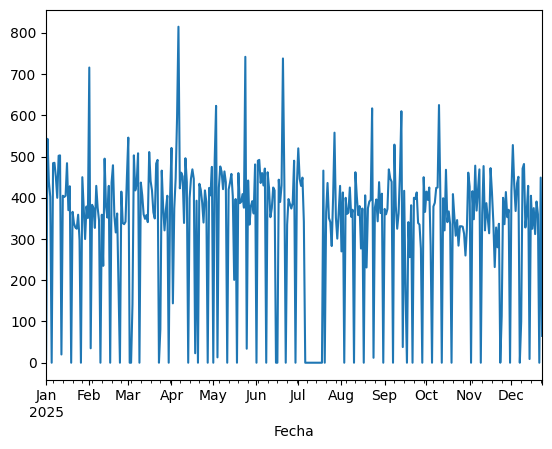

In [30]:
por_dia = df_copy.set_index("Fecha").resample("D").size()
por_dia.plot()

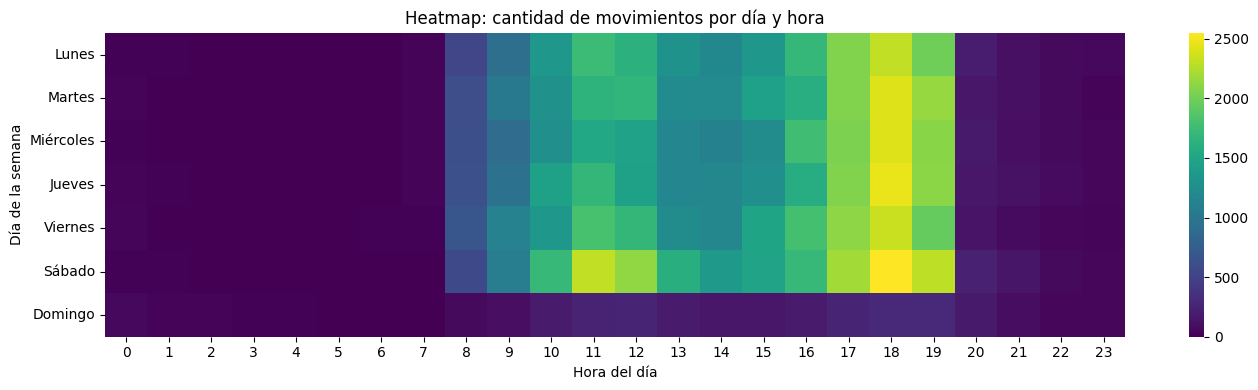

In [31]:
df_copy["day_num"] = df_copy["Fecha"].dt.dayofweek
df_copy["hour"] = df_copy["Fecha"].dt.hour

heat = pd.crosstab(df_copy["day_num"], df_copy["hour"])
heat = heat.reindex(index=range(7), columns=range(24), fill_value=0)

dias = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]

plt.figure(figsize=(14, 4))
sns.heatmap(heat, cmap="viridis") 
plt.yticks(ticks=[i+0.5 for i in range(7)], labels=dias, rotation=0)
plt.xticks(rotation=0)
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.title("Heatmap: cantidad de movimientos por día y hora")
plt.tight_layout()
plt.show()

In [32]:
cat_variables.remove("Fecha")
cat_variables.remove("Producto")

<Axes: xlabel='Rubro', ylabel='count'>

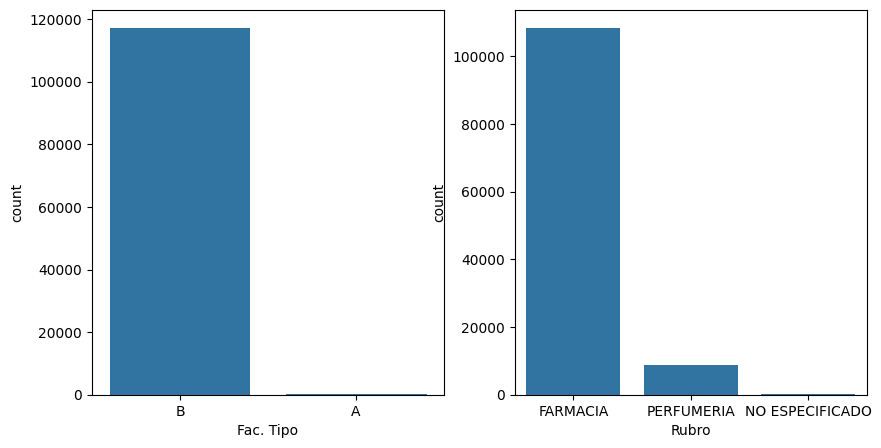

In [33]:
fig, axis = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(data=df, x=cat_variables[0], ax=axis[0])
sns.countplot(data=df, x=cat_variables[1], ax=axis[1])


#### Variable `Producto`

>Esta variable tiene muchos valores que son complicados de leer, como la trabajaremos a profundidad organizaremos y explicaremos en este espacio las decisiones que tomamos.
>
>Empezaremos por pasar todas las variables a minusculas y cambiar las ","(comas) por "."(puntos).

In [34]:
df["Producto"] = df["Producto"].fillna("").astype(str).str.lower().str.replace(",", ".", regex=False)
df["Producto"].value_counts()


Producto
gen lp ibuprofeno blister 600 mg x 10             1925
gen lp omeprazol blister 20 mg x 15               1203
aspirina prevent comp.cub.enterica x 50           1149
tafirol 1g x 8 (unica)                             870
tafirol 1 g comp.ran.x 50                          699
                                                  ... 
proair bronquial 500/50 cáps.p/inh.x 60+aplic.       1
flevomax 1000 mg comp.rec.x 30                       1
pampers pants premium care xgd                       1
aposito iqp (unica)                                  1
venda 7.5x2.5  (unica)                               1
Name: count, Length: 7672, dtype: int64

>Procederemos a borrar todos los productos que se vendieron menos de 12 veces en todo el año de datos que tenemos.
>Tambien haremos una revision a los nombres que tengan menos de 13 letras para verificar si queda algun error de tipografia donde no podamos sacar mas datos sobre el producto.

In [35]:
df = df[df["Producto"].map(df["Producto"].value_counts()) >= 12].copy()


In [36]:
mask = df["Producto"].fillna("").astype(str).str.len().le(12)
count_rows = mask.sum()
count_rows
df.loc[mask, "Producto"].astype(str).str.strip().value_counts()

Producto
dove (unica)    115
gum (unica)     108
idi (unica)      26
lima (unica)     24
evo (unica)      22
off (unica)      19
tuly (unica)     12
Name: count, dtype: int64

In [37]:
df["Producto"].value_counts()

Producto
gen lp ibuprofeno blister 600 mg x 10      1925
gen lp omeprazol blister 20 mg x 15        1203
aspirina prevent comp.cub.enterica x 50    1149
tafirol 1g x 8 (unica)                      870
tafirol 1 g comp.ran.x 50                   699
                                           ... 
barbijo tricapa                              12
rovartal ez 10 mg cáps. x 30                 12
istivac 4 jga.prell.x 1 x 0.5 ml             12
pisono 5 mg comp.rec.x 30                    12
iruxol ung.x 50 g                            12
Name: count, Length: 2005, dtype: int64

#### Observaciones

>Hasta este paso quitamos todos los productos que tuvieran menos de 12 ventas en todo el año y realizamos una revision de las variables que tuvieran menos de 12 letras, esto para filtrar los errores tipograficos como nombres cortos que no aporten nada. Aun asi no encontramos ninguno y continuamos.
>
>Nuestro siguiente paso es realizar una categorizacion a partir de la columna `Producto` donde crearemos la columna `product, dose, quantity` para clasificar los productos y poder entender mejor los datos.

In [38]:
df[["product", "dose", "quantity"]] = pd.NA

>Empezaremos poniendo las dosis segun los productos, para eso investigaremos sobre la nomenclatura de las dosis en argentina y crearemos un filtro que itere.

In [39]:
dose_pat = r"""(?ix)(
    \b\d+(?:\.\d+)?\s*/\s*\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\s*/\s*\d+(?:\.\d+)?\s*(?:ml|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*%(?!\w)                 # ✅ fix aquí
  | \b\d+\s*(?:dosis|ds)\b
  | (?<!\w)(?:unica|única)(?!\w)
)"""

df["dose"] = df["Producto"].str.findall(dose_pat).str.join(", ")
df["dose"] = df["dose"].str.replace(r"(?i)(?<!\w)(unica|única)(?!\w)", "UNICA", regex=True)
df["dose"] = df["dose"].replace("", np.nan)


>Verificamos que productos quedan en blanco despues de nuestro filtro.

In [40]:
df[
    df["dose"].fillna("").eq("")
][["Producto", "Rubro", "dose"]].value_counts()

Series([], Name: count, dtype: int64)

In [41]:
df[["Producto", "dose"]].value_counts()

Producto                               dose     
gen lp ibuprofeno blister 600 mg x 10  600 mg       1925
gen lp omeprazol blister 20 mg x 15    20 mg        1203
tafirol 1g x 8 (unica)                 1g, UNICA     870
tafirol 1 g comp.ran.x 50              1 g           699
gen lp diclofenac blister 75 mg x 15   75 mg         530
                                                    ... 
tacicul 50 mg comp.rec.x 30            50 mg          12
veraten ud 40 mg cáps.lib.ext.x 30     40 mg          12
aerotrop aer.hfa x 250 ds.             250 ds         12
acler cr.x 20 g                        20 g           12
zomarist 50 mg comp.x 56               50 mg          12
Name: count, Length: 1126, dtype: int64

>obtuvimos todas las dosis posibles y donde no existia un valor medible directamente decidimos dejarla en blanco con un NaN.
>
>Ahora procederemos a trabajar la columna `quantity`.

In [42]:
prod = df["Producto"].fillna("").astype(str)

qty_pat = r"""(?ix)(
    # 1) x <numero> <unidad> (incluye decimales) => volumen/peso
    \bx\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b                    # x 2.5 ml, x 100 ml, x 10 g

  | # 2) contenedores/presentación con unidad (opcional pero útil)
    \b(?:pomo|frasco|vial|amp(?:olla)?|sobre|sachet)\s*x?\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b

  | # 3) blister/env/caja/pack/test/aplic x N (incluye dosis)
    \b(?:pack|caja|env|sobre|sob|blister|blíster|test|aplic)\.?\s*x\s*\d{1,4}\s*(?:ds|dosis)?\b

  | # 4) comp/caps/grag/tab(.algo) x N
    \b(?:comp|comprimidos?|caps?|cáps?|grag|tab(?:s)?)(?:\.\w+)?\.?\s*x\s*\d{1,4}\b

  | # 5) x N (genérico, pero SOLO esto; evita 10 x 10)
    \bx\s*\d{1,4}\s*(?:ds|dosis)?\b

  | # 6) packs tipo 2x10 / 3x30 SOLO si está pegado (sin espacios) => evita 10 x 10
    \b\d{1,3}x\d{1,3}\b
)"""

df["quantity"] = prod.str.findall(qty_pat).str.join(", ")
df["quantity"] = df["quantity"].replace("", np.nan)


In [43]:
df[["Producto", "dose", "quantity"]].value_counts().head(20)

Producto                                  dose       quantity      
gen lp ibuprofeno blister 600 mg x 10     600 mg     x 10              1925
gen lp omeprazol blister 20 mg x 15       20 mg      x 15              1203
tafirol 1g x 8 (unica)                    1g, UNICA  x 8                870
tafirol 1 g comp.ran.x 50                 1 g        comp.ran.x 50      699
gen lp diclofenac blister 75 mg x 15      75 mg      x 15               530
corbis 5 mg comp.rec.x 30                 5 mg       comp.rec.x 30      471
t4 montpellier 75 75 mcg comp.x 50        75 mcg     comp.x 50          446
t4 montpellier 50 50 mcg comp.x 50        50 mcg     comp.x 50          423
t4 montpellier 100 100 mcg comp.x 50      100 mcg    comp.x 50          386
gen lp ibuprofeno blister 400 mg x 10     400 mg     x 10               368
acemuk 600 mg tab.eferv.x 10              600 mg     tab.eferv.x 10     350
lotrial 10 mg comp.x 60                   10 mg      comp.x 60          344
gen lp loratadina bl

>obtuvimos todas las cantidades posibles y donde no existia un valor medible directamente decidimos dejarla en blanco con un NaN.
>
>Ahora procederemos a trabajar la columna `product`.

In [44]:
prod = df["Producto"].fillna("").astype(str)

# --- 1) patrones a eliminar (dosis y cantidades/presentación) ---

dose_pat = r"""(?ix)(
    \b\d+(?:\.\d+)?\s*/\s*\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\s*/\s*\d+(?:\.\d+)?\s*(?:ml|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*%(?!\w)
  | \b\d+\s*(?:dosis|ds)\b
  | (?<!\w)(?:unica|única)(?!\w)
)"""

qty_remove_pat = r"""(?ix)(
    \bx\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b
  | \b(?:pack|caja|env|sobre|sob|blister|blíster|test|aplic)\.?\s*x\s*\d{1,4}\s*(?:ds|dosis)?\b
  | \b(?:comp|comprimidos?|caps?|cáps?|grag|tab(?:s)?)(?:\.\w+)?\.?\s*x\s*\d{1,4}\b
  | \bx\s*\d{1,4}\s*(?:ds|dosis)?\b
  | \b\d{1,3}x\d{1,3}\b
)"""

# --- 2) base: quitar dose + quantity del texto ---
p = (prod
     .str.replace(dose_pat, " ", regex=True)
     .str.replace(qty_remove_pat, " ", regex=True)
)

# --- 3) FIXES específicos ---
# 3.1) quitar números sueltos al final (ej: "... seda 50" -> "... seda")
p = p.str.replace(r"(?ix)\s+\d{1,4}(?:\.\d+)?\s*$", " ", regex=True)

# 3.2) quitar 'x' suelta (ej: "cr x" -> "cr")
p = p.str.replace(r"(?ix)(?<!\w)x(?!\w)", " ", regex=True)

# 3.3) quitar el número repetido que coincide con la dosis (diurex 25 25 mg -> diurex)
dose_num = df["dose"].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand=False)

def drop_repeated_num(text, num):
    if not isinstance(num, str) or num == "" or num.lower() == "nan":
        return text
    return re.sub(rf"(?<!\w){re.escape(num)}(?!\w)", " ", text)

p = pd.Series(
    (drop_repeated_num(t, n) for t, n in zip(p.tolist(), dose_num.tolist())),
    index=df.index
)

# --- 4) limpieza final: puntuación y espacios ---
df["product"] = (p
    .str.replace(r"[^\w\sáéíóúñü]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .replace("", np.nan)
)

# opcional: colapsa repeticiones tipo "gel gel" -> "gel"
df["product"] = df["product"].str.replace(
    r"(?ix)\b(\w+)\b(?:\s+\1\b)+", r"\1", regex=True
)

In [45]:
df[["Producto", "dose", "quantity", "product"]].value_counts()


Producto                               dose       quantity       product          
gen lp ibuprofeno blister 600 mg x 10  600 mg     x 10           gen lp ibuprofeno    1925
gen lp omeprazol blister 20 mg x 15    20 mg      x 15           gen lp omeprazol     1203
tafirol 1g x 8 (unica)                 1g, UNICA  x 8            tafirol               870
tafirol 1 g comp.ran.x 50              1 g        comp.ran.x 50  tafirol               699
gen lp diclofenac blister 75 mg x 15   75 mg      x 15           gen lp diclofenac     530
                                                                                      ... 
tritab 500 mg comp.rec.x 5             500 mg     comp.rec.x 5   tritab                 12
acler cr.x 20 g                        20 g       x 20 g         acler cr               12
triamid 500 mg comp.rec.x 3            500 mg     comp.rec.x 3   triamid                12
aerotrop aer.hfa x 250 ds.             250 ds     x 250 ds       aerotrop aer hfa       12
zomaris

In [46]:
df["product"].isna().sum()


np.int64(0)

In [47]:
df["product"].value_counts()

product
gen lp ibuprofeno                     2293
tafirol                               2133
t4 montpellier                        2055
aspirina prevent comp cub enterica    1239
gen lp omeprazol                      1203
                                      ... 
oxibron                                 12
barbijo tricapa                         12
istivac 4 jga prell                     12
tuly                                    12
veraten ud cáps lib ext                 12
Name: count, Length: 1511, dtype: int64

### Analisis de variables numericas

In [48]:
num_variables = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
num_variables

['Fac. Suc.',
 'Fac. Nun.',
 'Cant.',
 'Precio',
 'Sub. Total',
 'Cobertura',
 'Ajustes',
 'Desc. Adic.',
 'Total. Cliente',
 'IVA',
 'Tasa Iva',
 'Total Gravado',
 'Total sin Gravar',
 'num_semana']

In [49]:
df[num_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
Fac. Suc.,98239.0,0.000000,0.000000,0.00,0.000,0.00,0.000,0.0000
Fac. Nun.,98239.0,417426.945236,22334.863825,379923.00,397992.500,415906.00,437278.500,455865.0000
Cant.,98239.0,1.392970,1.820444,0.00,1.000,1.00,1.000,60.0000
Precio,98239.0,15209.087193,15054.711449,30.00,5456.195,10645.32,20363.060,226169.4800
Sub. Total,98239.0,15863.070920,18382.788547,0.00,5500.000,10629.00,20811.050,910135.8000
Cobertura,98239.0,7259.294582,14971.946834,-157953.92,0.000,0.00,10219.520,811668.0000
Ajustes,98239.0,0.000000,0.000000,0.00,0.000,0.00,0.000,0.0000
Desc. Adic.,98239.0,38.851857,605.745890,-31312.40,0.000,0.00,0.000,46319.9280
Total. Cliente,98239.0,8564.924480,8996.958749,0.00,3283.520,6200.00,11145.600,219374.7500
IVA,98239.0,213.962975,1622.061280,0.00,0.000,0.00,0.000,157957.4529


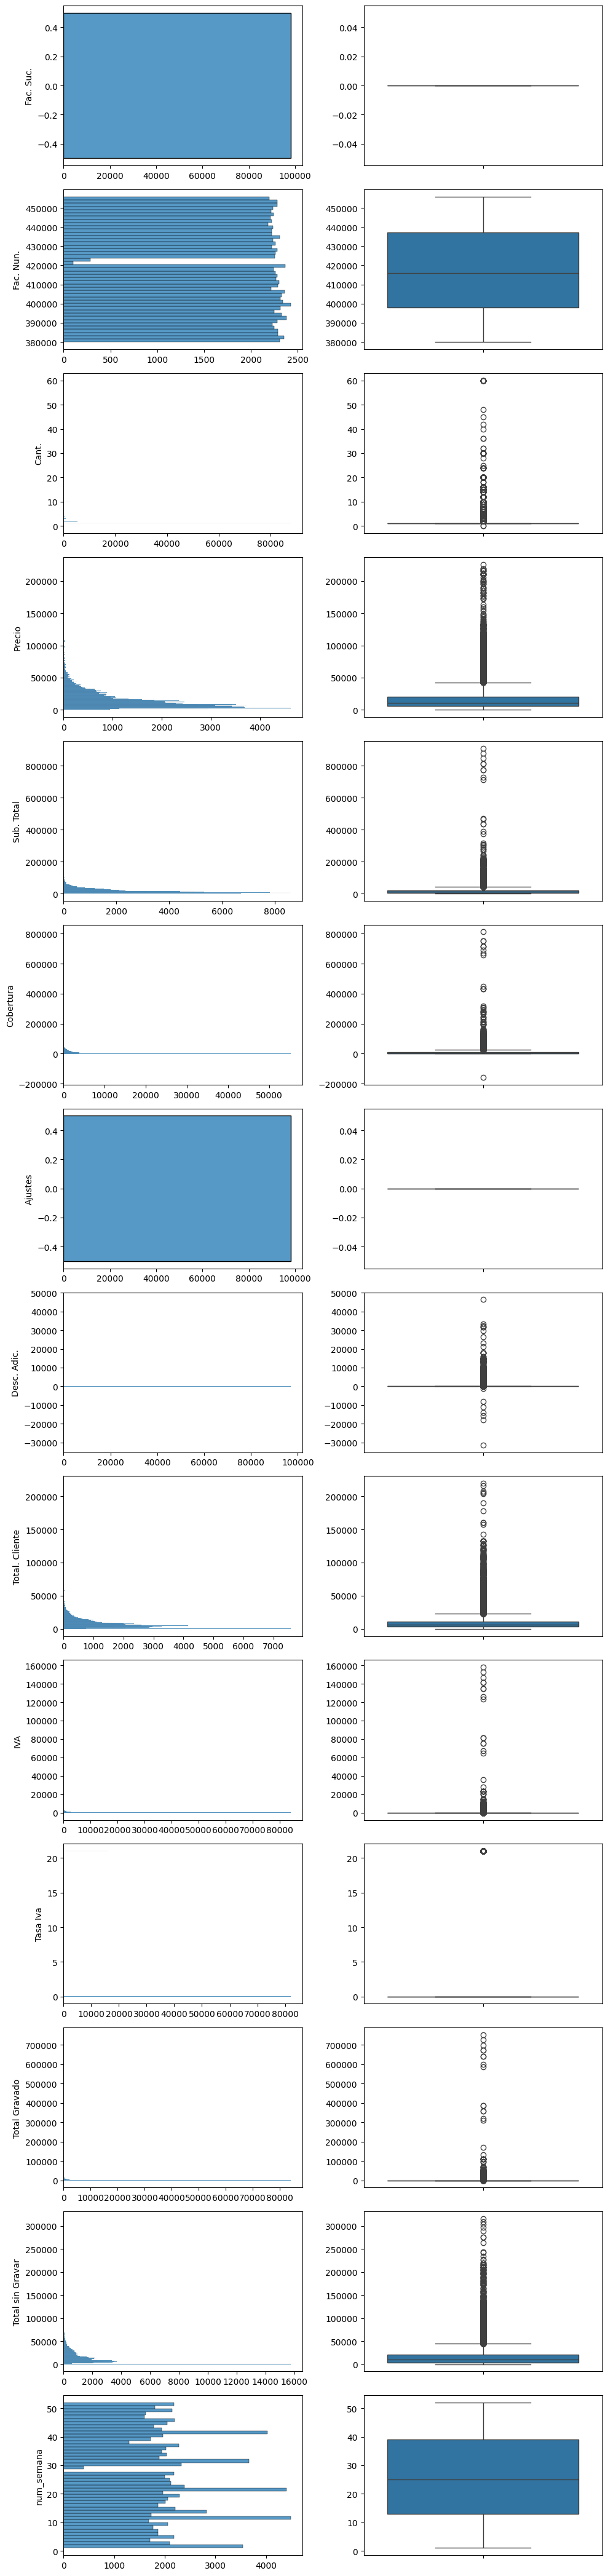

In [50]:
fig, axis = plt.subplots(len(num_variables), 2, figsize=(10, 3*len(num_variables)))

for i, var in enumerate(num_variables):
    sns.histplot(ax=axis[i, 0], data=df, y=var).set(xlabel=None)
    sns.boxplot(ax=axis[i, 1], data=df, y=var).set(ylabel=None)


plt.tight_layout()
plt.show()

#### Observaciones.

`Fac. Suc.` - Todos sus valores estan en 0, en una columna que no nos dice nada.  
`Fac. Nun.` - Es el numero de factura, como un id, tampoco nos aporta mucho a lo que buscamos.    
`Cant.` - Aunque la mayoria tienen como valor 1, el resto de outliner parecen ser reales, la conservaremos para tratarla detalladamente mas adelante.  
`Precio` - Es el precio por unidad que tiene un producto  
`Sub. Total` - Es el resultado de multiplicar el precio por cantidad   
`Cobertura` - Es lo que cubre la seguridad social.   
`Ajustes` - Todos sus valores estan en 0, en una columna que no nos dice nada.  
`Desc. Adic.` - Aunque la mayoria de los valores estan en 0, tiene numeros en negativos y positivos, tambien revisaremos a profundidad.  
`Total. Cliente` -  La mayoria de valores esta entre 0 y 25000, tiene varios outliners que debemos tomar en cuenta.  
`IVA` -  Esta variable va desde el 0 al 160000, tiene sentido ya que sera el iva por producto.  
`Tasa Iva` - esta entre 0, 10% y 21%    
`Total Gravado` -  los valores principalmente estan en 0, pero notamos algunos outliners que revisaremos a detalle  
`Total sin Gravar` -   Los valores estan entre 0 y 60000 aproximadamente, encontramos varios outliners que analizaremos lo que nos dice mas adelante.  

In [51]:
df = df.drop(columns=["Fac. Suc", "Fac. Nun.", "Ajustes"], errors="ignore")

In [52]:
df[["Producto", "Precio", "Sub. Total", "Cant.", "Cobertura", "Desc. Adic.", "Tasa Iva", "IVA","Total Gravado", "Total sin Gravar", "Total. Cliente"]].head(10)

,Producto,Precio,Sub. Total,Cant.,Cobertura,Desc. Adic.,Tasa Iva,IVA,Total Gravado,Total sin Gravar,Total. Cliente
0,actron pediatrico 4% susp.oral x 100 ml,9344.00,9344.00,1,0.00,0.0,0,0.000000,0.000000,9344.00,9344.00
1,amoxidal 500 mg comp.rec.x 21,8174.96,8174.96,1,3032.85,0.0,0,0.000000,0.000000,8174.96,5142.11
2,amoxidal 500 mg comp.rec.x 21,8174.96,8174.96,1,5318.10,0.0,0,0.000000,0.000000,8174.96,2856.86
3,muelita forte gel gel pomo x 10 g,8086.82,8086.82,1,0.00,0.0,0,0.000000,0.000000,8086.82,8086.82
4,dioxaflex b12 comp.x 20,26750.12,26750.12,1,0.00,0.0,0,0.000000,0.000000,26750.12,26750.12
5,evatest digital env.x 1,24480.51,24480.51,1,0.00,0.0,21,4248.683554,20231.826450,0.00,24480.51
6,gen lp ketorolac blister 20 mg x 10,4800.00,4800.00,1,0.00,0.0,0,0.000000,0.000000,4800.00,4800.00
7,cafiaspirina plus comp.x 20,4961.00,4961.00,1,0.00,0.0,0,0.000000,0.000000,4961.00,4961.00
8,accesorio (unica),3500.00,7000.00,2,0.00,0.0,21,1214.876033,5785.123967,0.00,7000.00
9,qura plus comp.rec.x 20,3430.00,3430.00,1,0.00,343.0,0,0.000000,0.000000,3430.00,3087.00


### Observaciones. Hasta este punto tenemos informacion suficiente para poder, según el modelo y el target, usar los datos para hacer predicciones de ML.

## Objetivos o targets a predecir.

### Objetivo 1: Predecir cantidad de productos vendidos por semana.

>Con los datos que tenemos nos parece viable hacer predicciones de ventas de productos. Ajustaremos y limpiaremos el DataSet en una copia para dejar los datos que tenemos hasta aca para otro tipo de predicciones.

In [53]:
df_obj_one = df.copy()

In [54]:
df_obj_one.head(5)

,Fecha,Fac. Tipo,Fac. Suc.,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar,num_semana,product,dose,quantity
0,2025-01-01 01:13:46,B,0,1,9344.00,actron pediatrico 4% susp.oral x 100 ml,9344.00,FARMACIA,0.00,0.0,9344.00,0.0,0,0.0,9344.00,1,actron pediatrico susp oral,4%,x 100 ml
1,2025-01-01 01:59:21,B,0,1,8174.96,amoxidal 500 mg comp.rec.x 21,8174.96,FARMACIA,3032.85,0.0,5142.11,0.0,0,0.0,8174.96,1,amoxidal,500 mg,comp.rec.x 21
2,2025-01-01 02:01:59,B,0,1,8174.96,amoxidal 500 mg comp.rec.x 21,8174.96,FARMACIA,5318.10,0.0,2856.86,0.0,0,0.0,8174.96,1,amoxidal,500 mg,comp.rec.x 21
3,2025-01-01 02:04:14,B,0,1,8086.82,muelita forte gel gel pomo x 10 g,8086.82,FARMACIA,0.00,0.0,8086.82,0.0,0,0.0,8086.82,1,muelita forte gel pomo,10 g,pomo x 10 g
4,2025-01-01 02:08:35,B,0,1,26750.12,dioxaflex b12 comp.x 20,26750.12,FARMACIA,0.00,0.0,26750.12,0.0,0,0.0,26750.12,1,dioxaflex b12,NaN,comp.x 20


In [55]:
cols_drop = ["Sub. Total", "IVA", "Tasa Iva", "Total Gravado",
            "Total sin Gravar", "Total. Cliente", "Cobertura",
            "Desc. Adic.", "Producto", "Fac. Tipo", "Fac. Suc.",
            "Precio", "quantity"]

df_obj_one = df.drop(columns=cols_drop, errors="ignore")

In [56]:
df_obj_one

,Fecha,Cant.,Rubro,num_semana,product,dose
0,2025-01-01 01:13:46,1,FARMACIA,1,actron pediatrico susp oral,4%
1,2025-01-01 01:59:21,1,FARMACIA,1,amoxidal,500 mg
2,2025-01-01 02:01:59,1,FARMACIA,1,amoxidal,500 mg
3,2025-01-01 02:04:14,1,FARMACIA,1,muelita forte gel pomo,10 g
4,2025-01-01 02:08:35,1,FARMACIA,1,dioxaflex b12,NaN
...,...,...,...,...,...,...
117288,2025-12-23 10:23:06,8,FARMACIA,52,mylanta extra,NaN
117289,2025-12-23 10:23:06,1,FARMACIA,52,colgate,UNICA
117290,2025-12-23 10:25:57,1,FARMACIA,52,tafirol,1 g
117292,2025-12-23 10:38:49,1,FARMACIA,52,louten t colirio,NaN


In [57]:
df.columns

Index(['Fecha', 'Fac. Tipo', 'Fac. Suc.', 'Cant.', 'Precio', 'Producto',
       'Sub. Total', 'Rubro', 'Cobertura', 'Desc. Adic.', 'Total. Cliente',
       'IVA', 'Tasa Iva', 'Total Gravado', 'Total sin Gravar', 'num_semana',
       'product', 'dose', 'quantity'],
      dtype='object')

In [58]:
import pandas as pd

# Asegurar datetime
df["Fecha"] = pd.to_datetime(df["Fecha"])

# Agregar ventas diarias por producto
df_prophet = (
    df.groupby(["Producto", "Fecha"])["Cant."]
      .sum()
      .reset_index()
)

# Renombrar columnas como Prophet necesita
df_prophet = df_prophet.rename(columns={
    "Fecha": "ds",
    "Cant.": "y"
})


In [59]:
from prophet import Prophet

producto_id = df_prophet["Producto"].iloc[0]  # ejemplo

df_p = df_prophet[df_prophet["Producto"] == producto_id][["ds", "y"]]

m = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

m.fit(df_p)


/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
09:24:33 - cmdstanpy - INFO - Chain [1] start processing
09:24:34 - cmdstanpy - INFO - Chain [1] done processing


In [60]:
future = m.make_future_dataframe(periods=30)  # 30 días
forecast = m.predict(future)


In [61]:
forecast_future = forecast.tail(30)

stock_30d = forecast_future["yhat"].sum()
print("Stock sugerido próximos 30 días:", round(stock_30d))


Stock sugerido próximos 30 días: 481


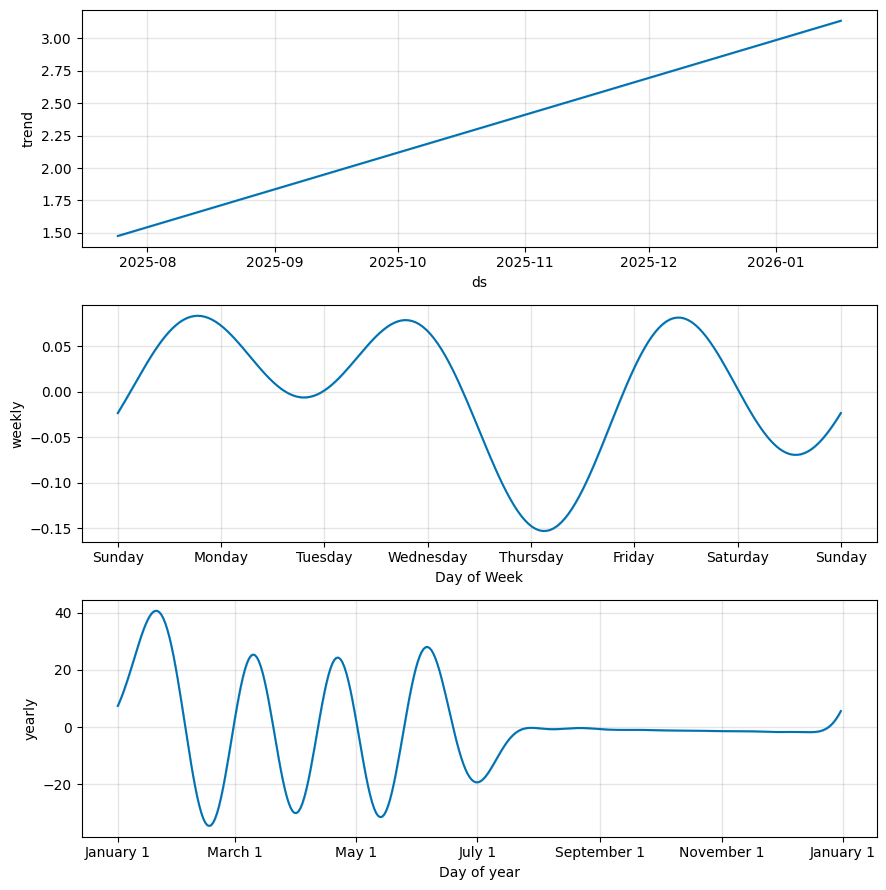

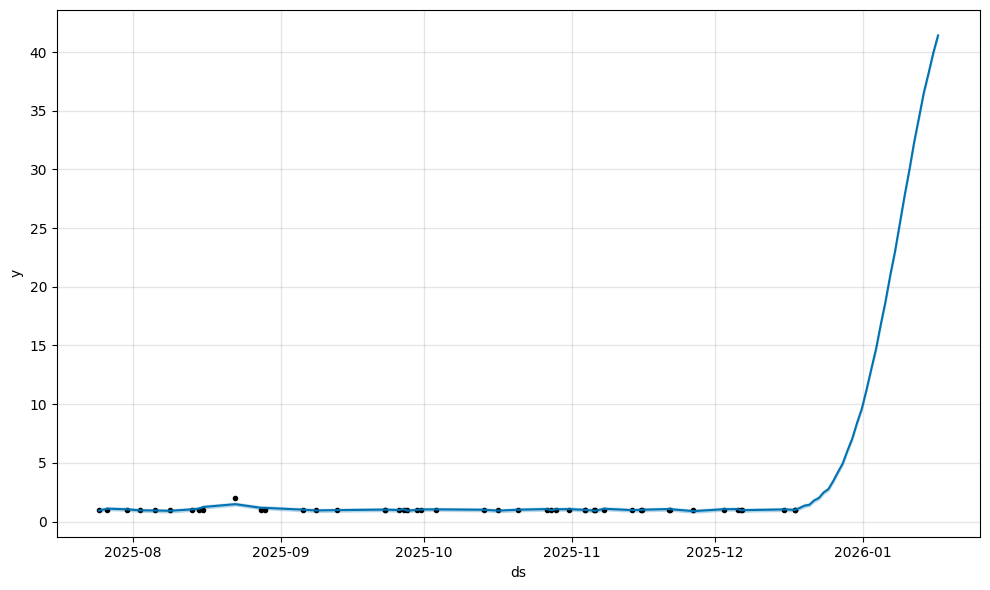

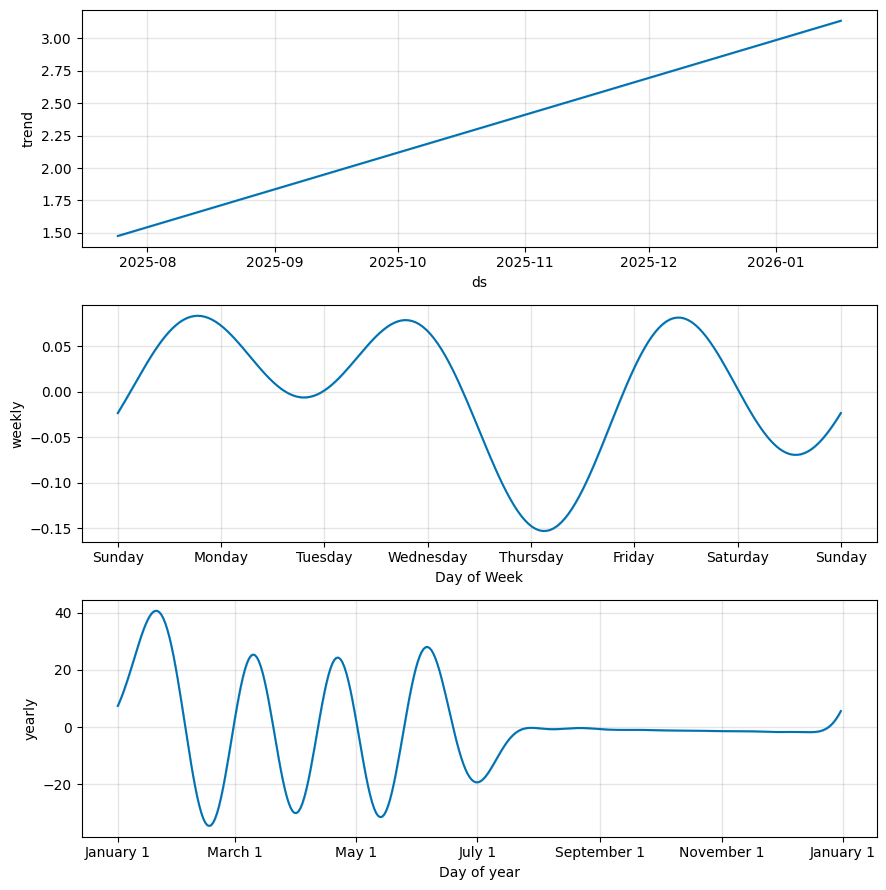

In [62]:
m.plot(forecast)
m.plot_components(forecast)


In [63]:
resultados = []

for prod in df_prophet["Producto"].unique():
    df_p = df_prophet[df_prophet["Producto"] == prod][["ds", "y"]]

    if len(df_p) < 60:   # mínimo de datos
        continue

    m = Prophet(weekly_seasonality=True, yearly_seasonality=True)
    m.fit(df_p)

    future = m.make_future_dataframe(periods=30)
    fc = m.predict(future)

    stock = fc.tail(30)["yhat"].sum()

    resultados.append({
        "Producto": prod,
        "Stock_30d": round(stock)
    })

df_stock = pd.DataFrame(resultados)


09:24:35 - cmdstanpy - INFO - Chain [1] start processing
09:24:35 - cmdstanpy - INFO - Chain [1] done processing


09:24:35 - cmdstanpy - INFO - Chain [1] start processing
09:24:35 - cmdstanpy - INFO - Chain [1] done processing
09:24:35 - cmdstanpy - INFO - Chain [1] start processing
09:24:35 - cmdstanpy - INFO - Chain [1] done processing
09:24:35 - cmdstanpy - INFO - Chain [1] start processing
09:24:36 - cmdstanpy - INFO - Chain [1] done processing
09:24:36 - cmdstanpy - INFO - Chain [1] start processing
09:24:36 - cmdstanpy - INFO - Chain [1] done processing
09:24:36 - cmdstanpy - INFO - Chain [1] start processing
09:24:36 - cmdstanpy - INFO - Chain [1] done processing
09:24:36 - cmdstanpy - INFO - Chain [1] start processing
09:24:36 - cmdstanpy - INFO - Chain [1] done processing
09:24:36 - cmdstanpy - INFO - Chain [1] start processing
09:24:36 - cmdstanpy - INFO - Chain [1] done processing
09:24:36 - cmdstanpy - INFO - Chain [1] start processing
09:24:36 - cmdstanpy - INFO - Chain [1] done processing
09:24:36 - cmdstanpy - INFO - Chain [1] start processing
09:24:36 - cmdstanpy - INFO - Chain [1]

XGBOOS PARA PREDECIR ENERO 2026

In [64]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error


In [65]:
df['Fecha'] = pd.to_datetime(df['Fecha'])

ventas = (
    df.groupby(['Fecha', 'Producto'])['Cant.']
      .sum()
      .reset_index()
      .rename(columns={'Cant.': 'cantidad'})
)

ventas.head()


,Fecha,Producto,cantidad
0,2025-01-01 01:13:46,actron pediatrico 4% susp.oral x 100 ml,1
1,2025-01-01 01:59:21,amoxidal 500 mg comp.rec.x 21,1
2,2025-01-01 02:01:59,amoxidal 500 mg comp.rec.x 21,1
3,2025-01-01 02:04:14,muelita forte gel gel pomo x 10 g,1
4,2025-01-01 02:08:35,dioxaflex b12 comp.x 20,1


In [66]:
all_dates = pd.date_range(ventas['Fecha'].min(), ventas['Fecha'].max(), freq='D')
all_products = ventas['Producto'].unique()

grid = pd.MultiIndex.from_product(
    [all_dates, all_products],
    names=['Fecha', 'Producto']
).to_frame(index=False)

ventas_full = grid.merge(ventas, on=['Fecha','Producto'], how='left')
ventas_full['cantidad'] = ventas_full['cantidad'].fillna(0)

ventas_full.head()


,Fecha,Producto,cantidad
0,2025-01-01 01:13:46,actron pediatrico 4% susp.oral x 100 ml,1.0
1,2025-01-01 01:13:46,amoxidal 500 mg comp.rec.x 21,0.0
2,2025-01-01 01:13:46,muelita forte gel gel pomo x 10 g,0.0
3,2025-01-01 01:13:46,dioxaflex b12 comp.x 20,0.0
4,2025-01-01 01:13:46,evatest digital env.x 1,0.0


In [67]:
ventas_full['dia'] = ventas_full['Fecha'].dt.day
ventas_full['mes'] = ventas_full['Fecha'].dt.month
ventas_full['anio'] = ventas_full['Fecha'].dt.year
ventas_full['dia_semana'] = ventas_full['Fecha'].dt.weekday
ventas_full['num_semana'] = ventas_full['Fecha'].dt.isocalendar().week.astype(int)

ventas_full.head()


,Fecha,Producto,cantidad,dia,mes,anio,dia_semana,num_semana
0,2025-01-01 01:13:46,actron pediatrico 4% susp.oral x 100 ml,1.0,1,1,2025,2,1
1,2025-01-01 01:13:46,amoxidal 500 mg comp.rec.x 21,0.0,1,1,2025,2,1
2,2025-01-01 01:13:46,muelita forte gel gel pomo x 10 g,0.0,1,1,2025,2,1
3,2025-01-01 01:13:46,dioxaflex b12 comp.x 20,0.0,1,1,2025,2,1
4,2025-01-01 01:13:46,evatest digital env.x 1,0.0,1,1,2025,2,1


In [68]:
for lag in [1, 7, 14, 30]:
    ventas_full[f'lag_{lag}'] = ventas_full.groupby('Producto')['cantidad'].shift(lag)

ventas_full['rolling_7']  = ventas_full.groupby('Producto')['cantidad'].shift(1).rolling(7).mean()
ventas_full['rolling_30'] = ventas_full.groupby('Producto')['cantidad'].shift(1).rolling(30).mean()

ventas_full.tail()


,Fecha,Producto,cantidad,dia,mes,anio,dia_semana,num_semana,lag_1,lag_7,lag_14,lag_30,rolling_7,rolling_30
715780,2025-12-23 01:13:46,nexdia 10 mg comp.rec.x 30,0.0,23,12,2025,1,52,0.0,0.0,0.0,0.0,0.0,0.0
715781,2025-12-23 01:13:46,tafirol 1 g blíster comp. x 8,0.0,23,12,2025,1,52,0.0,0.0,0.0,0.0,0.0,0.0
715782,2025-12-23 01:13:46,tafirol comp. x 10,0.0,23,12,2025,1,52,0.0,0.0,0.0,0.0,0.0,0.0
715783,2025-12-23 01:13:46,tafirol forte 650 mg blíst.x 8,0.0,23,12,2025,1,52,0.0,0.0,0.0,0.0,0.0,0.0
715784,2025-12-23 01:13:46,curitas transpiel 10 unid apo,0.0,23,12,2025,1,52,0.0,0.0,0.0,0.0,0.0,0.0


In [69]:
ventas_modelo = ventas_full.dropna().copy()
ventas_modelo.shape


(655635, 14)

In [ ]:
X = ventas_modelo.drop(columns=['cantidad','Fecha'])
y = ventas_modelo['cantidad']

X = pd.get_dummies(X, columns=['Producto'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)


: 

In [ ]:
model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)


In [ ]:
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print("MAE:", mae)


In [ ]:
from datetime import timedelta

future_dates = pd.date_range("2026-01-01", "2026-01-31", freq='D')
predicciones = []

ultimo_df = ventas_full.copy()

for fecha in future_dates:
    for prod in all_products:
        fila = ultimo_df[(ultimo_df['Fecha'] == ultimo_df['Fecha'].max()) & 
                          (ultimo_df['Producto'] == prod)].copy()
        
        fila['Fecha'] = fecha
        fila['dia'] = fecha.day
        fila['mes'] = fecha.month
        fila['anio'] = fecha.year
        fila['dia_semana'] = fecha.weekday()
        fila['num_semana'] = fecha.isocalendar().week

        for lag in [1,7,14,30]:
            fila[f'lag_{lag}'] = ultimo_df[ultimo_df['Producto']==prod].sort_values('Fecha')['cantidad'].iloc[-lag]

        fila['rolling_7'] = ultimo_df[ultimo_df['Producto']==prod].sort_values('Fecha')['cantidad'].iloc[-7:].mean()
        fila['rolling_30'] = ultimo_df[ultimo_df['Producto']==prod].sort_values('Fecha')['cantidad'].iloc[-30:].mean()

        X_fila = fila.drop(columns=['cantidad','Fecha'])
        X_fila = pd.get_dummies(X_fila, columns=['Producto'], drop_first=True)
        X_fila = X_fila.reindex(columns=X_train.columns, fill_value=0)

        pred = model.predict(X_fila)[0]
        fila['cantidad'] = max(0, pred)

        ultimo_df = pd.concat([ultimo_df, fila], ignore_index=True)
        predicciones.append(fila[['Fecha','Producto','cantidad']])


In [ ]:
pred_df = pd.concat(predicciones)
pred_df.head()


In [ ]:
stock_enero = pred_df.groupby('Producto')['cantidad'].sum().reset_index()
stock_enero = stock_enero.sort_values('cantidad', ascending=False)

stock_enero.head(10)
